# Random Survival Forest & Cox Proportional Hazards Model
## AIDS Survival Analysis - Model Training and Evaluation

This notebook trains and evaluates a Cox Proportional Hazards model on the AIDS Classification dataset.

**Workflow:**
1. Data Loading & Exploration
2. Feature Preparation
3. Data Splitting (70-21-9)
4. Data Preprocessing
5. CoxPH Model Training
6. Model Evaluation
7. Results Visualization

## 1. Environment Setup
### Import Required Libraries and Configure Settings

In [1]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-whitegrid')

# Set high-resolution output for all figures (1000 DPI)
plt.rcParams["figure.dpi"] = 1000
plt.rcParams["savefig.dpi"] = 1000

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")

# Survival analysis libraries
from sksurv.util import Surv
from sksurv.metrics import (
    concordance_index_censored,
    brier_score,
    cumulative_dynamic_auc,
    concordance_index_ipcw,
    integrated_brier_score
)
from sksurv.linear_model import CoxPHSurvivalAnalysis

# Machine learning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

## 2. Data Loading & Exploration
### Load Dataset and Inspect Basic Properties

In [2]:
# Load the AIDS Classification dataset
df = pd.read_csv("AIDS_Classification_50000.csv")

### Preview Dataset

In [3]:
# Display first few rows to understand data structure
df.head()

,time,trt,age,wtkg,hemo,homo,drugs,karnof,oprior,z30,...,str2,strat,symptom,treat,offtrt,cd40,cd420,cd80,cd820,infected
0,1073,1,37,79.46339,0,1,0,100,0,1,...,1,2,0,1,0,322,469,882,754,1
1,324,0,33,73.02314,0,1,0,90,0,1,...,1,3,1,1,1,168,575,1035,1525,1
2,495,1,43,69.47793,0,1,0,100,0,1,...,1,1,0,0,0,377,333,1147,1088,1
3,1201,3,42,89.15934,0,1,0,100,1,1,...,1,3,0,0,0,238,324,775,1019,1
4,934,0,37,137.46581,0,1,0,100,0,0,...,0,3,0,0,1,500,443,1601,849,0


### Dataset Information

In [4]:
# Display comprehensive dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 23 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   time      50000 non-null  int64  
 1   trt       50000 non-null  int64  
 2   age       50000 non-null  int64  
 3   wtkg      50000 non-null  float64
 4   hemo      50000 non-null  int64  
 5   homo      50000 non-null  int64  
 6   drugs     50000 non-null  int64  
 7   karnof    50000 non-null  int64  
 8   oprior    50000 non-null  int64  
 9   z30       50000 non-null  int64  
 10  preanti   50000 non-null  int64  
 11  race      50000 non-null  int64  
 12  gender    50000 non-null  int64  
 13  str2      50000 non-null  int64  
 14  strat     50000 non-null  int64  
 15  symptom   50000 non-null  int64  
 16  treat     50000 non-null  int64  
 17  offtrt    50000 non-null  int64  
 18  cd40      50000 non-null  int64  
 19  cd420     50000 non-null  int64  
 20  cd80      50000 non-null  in

### Check for Missing Values

In [5]:
# Display total missing values across all features
print(f"Total missing values: {df.isnull().sum().sum()}")

Total missing values: 0


## 3. Feature Engineering
### Prepare Features and Target Variables

**Target Variables:**
- `time`: Survival time in days
- `infected`: Event indicator (1=event occurred, 0=censored)

**Features:** All remaining columns

In [6]:
# Define column names for time-to-event and event indicator
time_col = "time"
event_col = "infected"

# Separate features from target variables
X = df.drop(columns=[time_col, event_col])
y_time = df[time_col].values
y_event = df[event_col].values.astype(bool)  # Convert to boolean for sksurv

### Compute Time Horizons for Evaluation

Calculate quartile-based time points (25th, 50th, 75th percentiles) from observed event times.
These will be used for time-dependent evaluation metrics.

In [7]:
# Extract time and event data
t = df[time_col].values
e = df[event_col].values

# Define horizons as quartiles (25%, 50%, 75%)
horizons = [0.25, 0.5, 0.75]

# Compute time points at these quartiles from OBSERVED events only
times = np.quantile(t[e == 1], horizons).tolist()
print(times)

[496.0, 992.0, 1127.0]


### Identify Categorical and Numerical Features

- **Categorical:** Features with less than 10 unique values
- **Numerical:** All other features

In [8]:
# Identify categorical columns (features with < 10 unique values)
cat_cols = [col for col in X.columns if X[col].nunique() < 10]

# Remaining columns are numerical
num_cols = [col for col in X.columns if col not in cat_cols]

## 4. Data Splitting Strategy
### Train-Test-Validation Split

**Split Ratios:**
- Training: 70% (~35,000 samples)
- Testing: 21% (~10,480 samples after filtering)
- Validation: 9% (~4,495 samples after filtering)

**Important:** Samples with time values exceeding the maximum training time are removed from test/validation sets to ensure proper model evaluation.

In [9]:
# First split: separate training set (70%) from temporary set (30%)
x_train, x_temp, t_train, t_temp, e_train, e_temp = train_test_split(
    X, y_time, y_event,
    test_size=0.30,
    random_state=42,
    stratify=e  # Maintain event ratio across splits
)

# Second split: divide temporary set into test (70% of 30%) and validation (30% of 30%)
x_test, x_val, t_test, t_val, e_test, e_val = train_test_split(
    x_temp, t_temp, e_temp,
    test_size=0.30,
    random_state=42,
    stratify=e_temp
)

# Remove samples from test set where time exceeds max training time
# This prevents evaluation on times beyond what the model was trained on
mask_test = t_test < t_train.max()
x_test = x_test[mask_test]
t_test = t_test[mask_test]
e_test = e_test[mask_test]

# Similarly filter validation set
mask_val = t_val < t_train.max()
x_val = x_val[mask_val]
t_val = t_val[mask_val]
e_val = e_val[mask_val]

# Prepare sksurv format targets (structured arrays)
y_train_surv = Surv.from_arrays(e_train.astype(bool), t_train)
y_test_surv = Surv.from_arrays(e_test.astype(bool), t_test)
y_val_surv = Surv.from_arrays(e_val.astype(bool), t_val)

# Display final sample sizes after filtering
print(f"Train shape: {x_train.shape}")
print(f"Test shape: {x_test.shape}")
print(f"Validation shape: {x_val.shape}")

Train shape: (35000, 21)
Test shape: (10480, 21)
Validation shape: (4495, 21)


## 5. Data Preprocessing
### Feature Scaling and Encoding

**Preprocessing Steps:**
- **Numerical features:** StandardScaler (z-score normalization)
- **Categorical features:** OneHotEncoder (drop first category to avoid multicollinearity)

In [10]:
# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        (
            "cat",
            OneHotEncoder(drop="first", handle_unknown="ignore"),
            cat_cols,
        ),
    ],
    remainder="passthrough",  # Keep any other columns unchanged
)

### Apply Preprocessing to Training and Test Sets

In [11]:
# Fit preprocessor on training data and transform both train and test sets
x_train_scaled = preprocessor.fit_transform(x_train)
x_test_scaled = preprocessor.transform(x_test)

## 6. Model Training
### Cox Proportional Hazards Model (scikit-survival)

We use the best hyperparameters identified through GridSearchCV:
- **alpha:** 21.54434690031882 (L2 regularization parameter)

#### Hyperparameter Tuning (Commented Out - Already Completed)

The following cells show the hyperparameter search that was performed.
The best alpha value has been used in the final model below.

In [12]:
# # Hyperparameter tuning function
# def cindex_scorer(estimator, X, y):
#     risk = X @ estimator.coef_
#     return concordance_index_censored(y["event"], y["time"], risk)[0]

In [13]:
# # Hyperparameter tuning
#
# param_grid = {"alpha": np.logspace(-4, 2, 10)}
#
# cox = CoxPHSurvivalAnalysis()
#
# gs_cox = GridSearchCV(cox, param_grid, scoring=cindex_scorer, cv=5, n_jobs=-1)
#
# gs_cox.fit(X_train, y_train_surv)
#
# best_cox = gs_cox.best_estimator_
# print("Best CoxPH alpha:", gs_cox.best_params_)

#### Best CoxPH alpha: {'alpha': 21.54434690031882}

### Train Final CoxPH Model with Best Hyperparameters

In [14]:
# Initialize and train CoxPH model with optimal alpha
cox = CoxPHSurvivalAnalysis(alpha=21.54434690031882)
cox.fit(x_train_scaled, y_train_surv)

CoxPHSurvivalAnalysis(alpha=21.54434690031882)

## 7. Model Evaluation
### Generate Predictions

**Prediction Types:**
- **Risk scores:** Continuous values for ranking patients
- **Survival functions:** Time-dependent survival probabilities
- **Risk at specific times:** Cumulative incidence approximation for AUC calculation

In [15]:
# Generate risk scores (higher = higher risk)
risk_scores = cox.predict(x_test_scaled)

# Generate survival functions for each test sample
surv_funcs = cox.predict_survival_function(x_test_scaled)

# Get probability of survival at specific time horizons
surv_probs = np.array([[fn(t) for t in times] for fn in surv_funcs])

# Convert to cumulative incidence (risk) for AUC calculation
risk_at_times = 1 - surv_probs

# For global C-index, use the single risk score
global_risk = risk_scores

### Calculate Performance Metrics

**Metrics Computed:**
1. **Time-Dependent C-Index (IPCW):** Concordance at specific time points
2. **Brier Score:** Prediction error at specific time points
3. **Time-Dependent AUC:** Discrimination at specific time points
4. **Integrated Metrics:** Overall performance across all time points

In [16]:
# Initialize results storage
results_quartile = []
results_global = []

# Calculate metrics for each time horizon (quartile)
for i, t_val in enumerate(times):
    # Time-dependent C-index (Inverse Probability of Censoring Weighting)
    # CoxPH has proportional hazards - single risk score valid for all times
    # Using time-specific risk surface (1-Surv) for better accuracy
    current_risk = risk_at_times[:, i]

    ctd = concordance_index_ipcw(y_train_surv, y_test_surv, current_risk, t_val)[0]

    # Brier Score at specific time point
    # Lower is better (prediction error)
    bs = brier_score(y_train_surv, y_test_surv, surv_probs[:, i].reshape(-1, 1), [t_val])[1][0]

    # Cumulative Dynamic AUC at specific time point
    # Higher is better (discrimination ability)
    auc_val_tuple = cumulative_dynamic_auc(y_train_surv, y_test_surv, current_risk, t_val)
    auc = auc_val_tuple[0][0]

    # Store quartile-specific results
    results_quartile.append({
        "Quartile_Time": t_val,
        "Quartile_Idx": f"Q{i+1}",
        "C-Index (TD)": ctd,
        "Brier Score": bs,
        "AUC Score": auc
    })

# --- Global Metrics ---
# Integrated Brier Score (average across all time points)
ibs = integrated_brier_score(y_train_surv, y_test_surv, surv_probs, times)

# Integrated AUC (average across all time points)
_, i_auc = cumulative_dynamic_auc(y_train_surv, y_test_surv, risk_at_times, times)

# Global Concordance (Traditional C-index for censored data)
# Note: For time-varying risk models, this uses a representative risk score
c_global = concordance_index_censored(y_test_surv["event"], y_test_surv["time"], global_risk)[0]

# Store global results
results_global.append({
    "Integrated Brier Score": ibs,
    "Integrated ROC-AUC": i_auc,
    "Global C-Index": c_global
})

# Convert results to DataFrames for display
df_quartile = pd.DataFrame(results_quartile)
df_global = pd.DataFrame(results_global)

### Display Results

**Quartile-Specific Metrics:**
- Performance at 25th, 50th, and 75th percentile time points

In [17]:
# Display quartile-specific results
display(df_quartile)

# Display global/integrated results
display(df_global)

,Quartile_Time,Quartile_Idx,C-Index (TD),Brier Score,AUC Score
0,496.0,Q1,0.698695,0.070929,0.706847
1,992.0,Q2,0.684666,0.139520,0.697676
2,1127.0,Q3,0.657435,0.205832,0.657372


,Integrated Brier Score,Integrated ROC-AUC,Global C-Index
0,0.119656,0.682507,0.670418


## 8. Additional Visualization
### 8.1 Feature Importance



In [19]:
# Get the actual feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()
# Now create the feature importance series
feature_importance = pd.Series(cox.coef_, index=feature_names)
feature_importance.sort_values(key=abs).plot.barh(figsize=(10, 8))
plt.xlabel("Coefficient (Log Hazard Ratio)")
plt.title("CoxPH Feature Importance")
plt.tight_layout()
plt.show()

### 8.2. Predicted Survival Curves

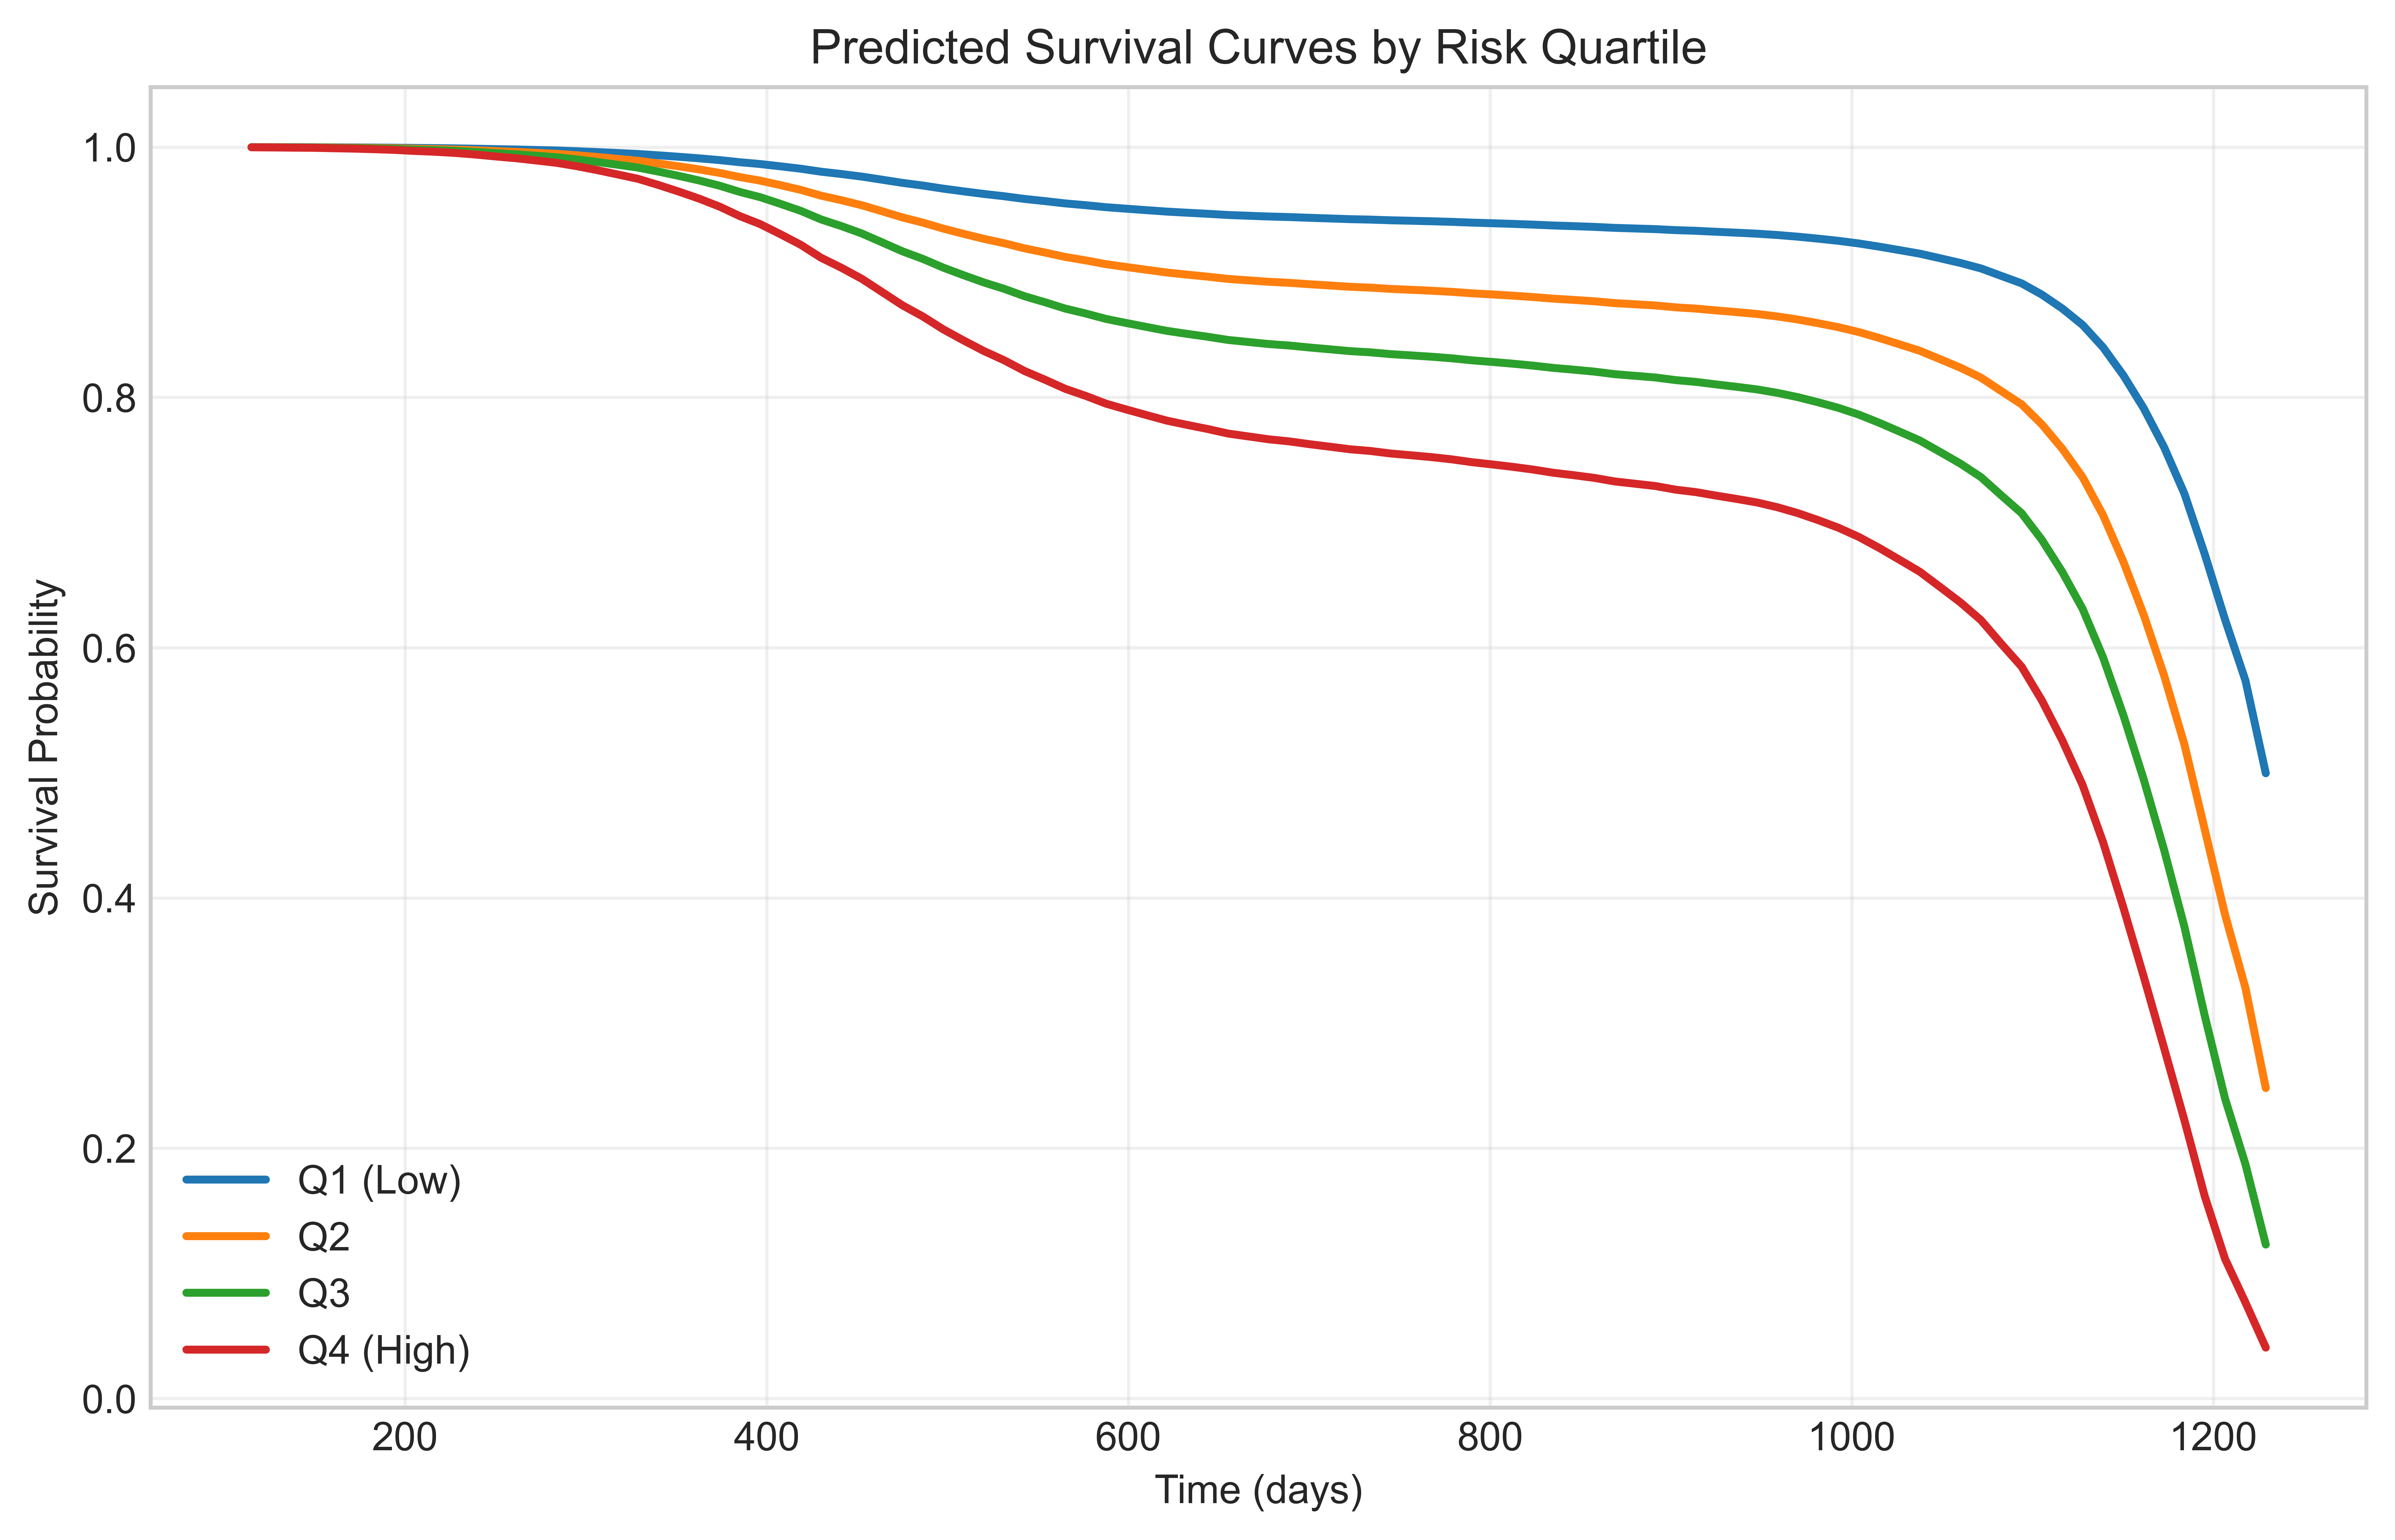

In [20]:
# Split test set into risk quartiles
risk_scores = cox.predict(x_test_scaled)
quartiles = pd.qcut(risk_scores, q=4, labels=['Q1 (Low)', 'Q2', 'Q3', 'Q4 (High)'])
# Plot survival curves
time_points = np.linspace(t_test.min(), t_test.max(), 100)
plt.figure(figsize=(10, 6))
for q in ['Q1 (Low)', 'Q2', 'Q3', 'Q4 (High)']:
    mask = quartiles == q
    surv_funcs = cox.predict_survival_function(x_test_scaled[mask])
    
    # Average survival function for this quartile
    surv_avg = np.mean([fn(time_points) for fn in surv_funcs[:20]], axis=0)  # Use first 20 for speed
    plt.plot(time_points, surv_avg, label=q, linewidth=2)
plt.xlabel('Time (days)')
plt.ylabel('Survival Probability')
plt.title('Predicted Survival Curves by Risk Quartile')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()